In [1]:
import numpy as np

from stable_baselines3 import DDPG
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.env_util import make_vec_env
from src.callback import TrainingCallback, env_callback

In [2]:
env = env_callback()
n_actions = env.action_space.shape[-1]
vec_env = make_vec_env(env_callback, n_envs=256)

model = DDPG(
    "MlpPolicy",
    vec_env,
    action_noise=NormalActionNoise(
        mean=np.zeros(n_actions),
        sigma=0.5 * np.ones(n_actions),
    ),
    verbose=0,
    tensorboard_log="results",
)

/home/atkinssamuel/miniconda3/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


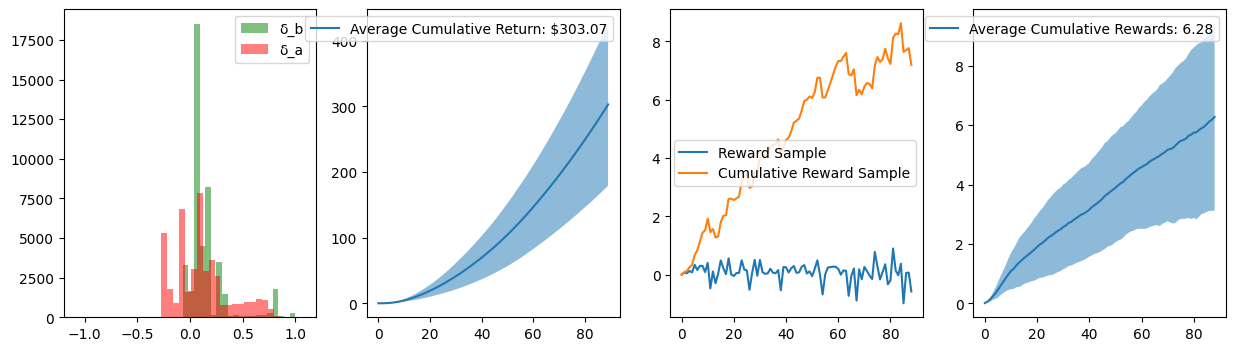


Timestep: 20000000


In [3]:
# to load already trained model
model = DDPG.load("models/DDPG_000_steps")
model.env = vec_env

model.learn(
    total_timesteps=20000000,
    callback=[
        TrainingCallback(1000, env),
        CheckpointCallback(1000, "models", name_prefix="DDPG"),
    ],
)

In [4]:
model.save("DDPG")